# **Heart Disease Risk Analysis**

This project analyzes clinical data to identify patterns and risk factors associated with heart disease.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load dataset
df = pd.read_csv('heart.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (303, 14)


# **Data Cleaning**

In this section, the dataset is cleaned and preprocessed by renaming columns, handling missing values, and converting variables into a more interpretable format.

In [ ]:
# Check missing values
df.isnull().sum()

# Check duplicates
df.duplicated().sum()

# Handle if needed
df.drop_duplicates(inplace=True)

In [ ]:
print("--- First 5 rows ---")
display(df.head())

print("\n--- Data types & null counts ---")
df.info()

print("\n--- Summary statistics ---")
display(df.describe().round(2))

--- First 5 rows ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



--- Data types & null counts ---
<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB

--- Summary statistics ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00
mean,54.42,0.68,0.96,131.60,246.50,0.15,0.53,149.57,0.33,1.04,1.40,0.72,2.31,0.54
std,9.05,0.47,1.03,17.56,51.75,0.36,0.53,22.90,0.47,1.16,0.62,1.01,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,133.25,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.50,1.00,1.00,130.00,240.50,0.00,1.00,152.50,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.75,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [ ]:
# Column names are already clean — just rename a few for clarity
df = df.rename(columns={
    'cp': 'chest_pain_type',
    'trestbps': 'resting_bp',
    'chol': 'cholesterol',
    'fbs': 'fasting_blood_sugar',
    'restecg': 'rest_ecg',
    'thalach': 'max_heart_rate',
    'exang': 'exercise_angina',
    'oldpeak': 'st_depression',
    'ca': 'num_vessels'
})

# Map binary columns to readable labels
df['sex'] = df['sex'].map({1: 'Male', 0: 'Female'})
df['target'] = df['target'].map({1: 'Disease', 0: 'No Disease'})
df['fasting_blood_sugar'] = df['fasting_blood_sugar'].map({1: '>120mg/dl', 0: '<=120mg/dl'})
df['thal'] = df['thal'].map({1: 'Normal', 2: 'Fixed Defect', 3: 'Reversible Defect'})
df['exercise_angina'] = df['exercise_angina'].map({1: 'Yes', 0: 'No'})

print("✓ No missing values:", df.isnull().sum().sum())
print("✓ Columns renamed successfully")
print("\nUpdated columns:", list(df.columns))
display(df.head())

✓ No missing values: 2
✓ Columns renamed successfully

Updated columns: ['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'rest_ecg', 'max_heart_rate', 'exercise_angina', 'st_depression', 'slope', 'num_vessels', 'thal', 'target']


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate,exercise_angina,st_depression,slope,num_vessels,thal,target
0,63,Male,3,145,233,>120mg/dl,0,150,No,2.3,0,0,Normal,Disease
1,37,Male,2,130,250,<=120mg/dl,1,187,No,3.5,0,0,Fixed Defect,Disease
2,41,Female,1,130,204,<=120mg/dl,0,172,No,1.4,2,0,Fixed Defect,Disease
3,56,Male,1,120,236,<=120mg/dl,1,178,No,0.8,2,0,Fixed Defect,Disease
4,57,Female,0,120,354,<=120mg/dl,1,163,Yes,0.6,2,0,Fixed Defect,Disease


# **Dataset Overview**

The dataset contains clinical attributes used to analyze the presence of heart disease in patients.

Several columns were cleaned and renamed for better interpretability. Additionally, categorical variables were mapped to human-readable values.

### Key Features:

- **age**: Age of the patient  
- **sex**: Gender (Male / Female)  
- **chest_pain_type**: Type of chest pain experienced  
- **resting_bp**: Resting blood pressure (mm Hg)  
- **cholesterol**: Serum cholesterol level (mg/dl)  
- **fasting_blood_sugar**: Blood sugar level (>120 mg/dl or ≤120 mg/dl)  
- **rest_ecg**: Resting electrocardiographic results  
- **max_heart_rate**: Maximum heart rate achieved  
- **exercise_angina**: Exercise-induced angina (Yes / No)  
- **st_depression**: ST depression induced by exercise  
- **num_vessels**: Number of major vessels colored by fluoroscopy  
- **thal**: Thalassemia condition  
- **target**: Presence of heart disease (Disease / No Disease)

# **Exploratory Data Analysis (EDA)**

In this section, we visualize different features to understand their relationship with heart disease.

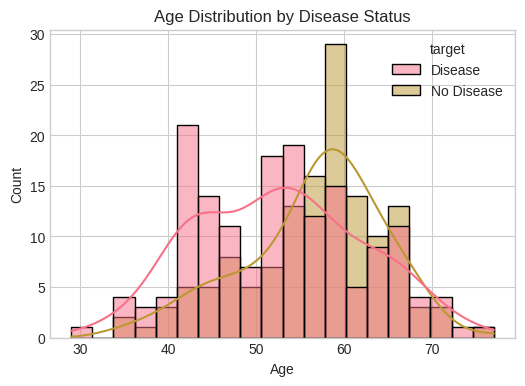

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='age', hue='target', bins=20, kde=True)
plt.title("Age Distribution by Disease Status")
plt.xlabel("Age")
plt.show()

### Insight:
Most patients with heart disease fall in the middle to older age groups, which suggests that the risk of heart disease increases with age.

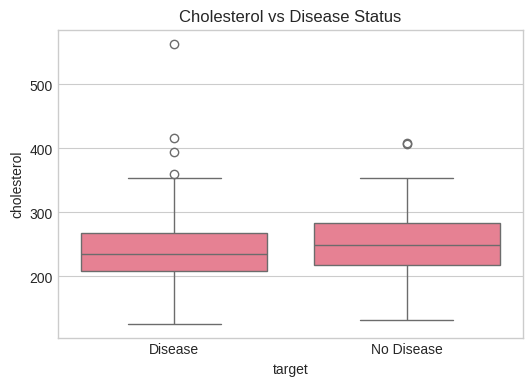

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='target', y='cholesterol')
plt.title("Cholesterol vs Disease Status")
plt.show()

### Insight:
Cholesterol levels are quite similar for both groups, so it does not seem to clearly separate patients with and without heart disease in this dataset.

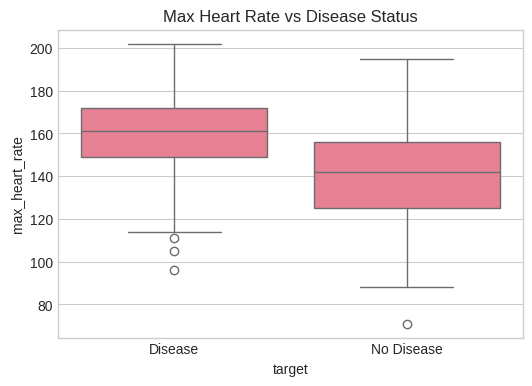

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='target', y='max_heart_rate')
plt.title("Max Heart Rate vs Disease Status")
plt.show()

### Insight:
Patients with heart disease generally have lower maximum heart rates, which may indicate reduced heart performance.

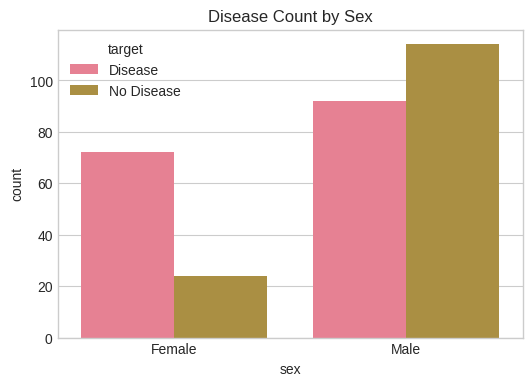

In [ ]:
sex_disease = df.groupby(['sex', 'target']).size().reset_index(name='count')

plt.figure(figsize=(6,4))
sns.barplot(data=sex_disease, x='sex', y='count', hue='target')
plt.title("Disease Count by Sex")
plt.show()

### Insight:
Heart disease cases are higher in males compared to females in this dataset.

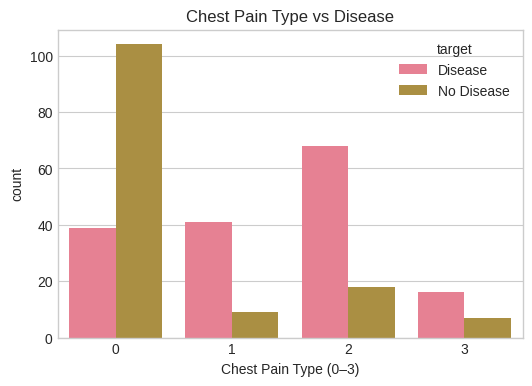

In [ ]:
cp_disease = df.groupby(['chest_pain_type', 'target']).size().reset_index(name='count')

plt.figure(figsize=(6,4))
sns.barplot(data=cp_disease, x='chest_pain_type', y='count', hue='target')
plt.title("Chest Pain Type vs Disease")
plt.xlabel("Chest Pain Type (0–3)")
plt.show()
df['chest_pain_type'] = df['chest_pain_type'].map({
    0: 'Typical Angina',
    1: 'Atypical Angina',
    2: 'Non-anginal Pain',
    3: 'Asymptomatic'
})

### Insight:
Heart disease is more common in patients with asymptomatic, atypical angina, and non-anginal chest pain, while typical angina is less frequently observed.

# **Correlation Analysis**

Understanding relationships between numerical features.

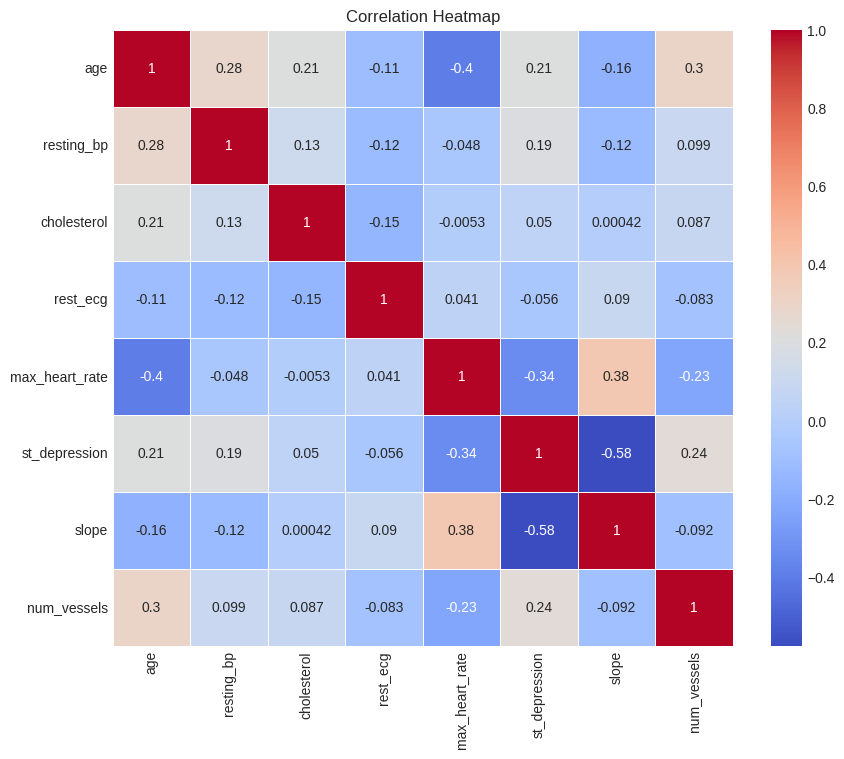

In [ ]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Insight:
Chest pain type and maximum heart rate show stronger relationships with heart disease, while cholesterol does not show a strong connection.


In [ ]:
df.groupby('target')[['age', 'cholesterol', 'max_heart_rate']].mean()

,age,cholesterol,max_heart_rate
target,,,
Disease,52.585366,242.640244,158.378049
No Disease,56.601449,251.086957,139.101449


In [ ]:
df.groupby('sex')['target'].value_counts(normalize=True).mul(100).unstack()

target,Disease,No Disease
sex,,
Female,75.000000,25.000000
Male,44.660194,55.339806


## Key Insights

- Patients without heart disease are slightly older on average compared to those with heart disease in this dataset.
- Cholesterol levels are similar across both groups, suggesting it may not be a strong standalone indicator.
- Patients with heart disease tend to have higher maximum heart rates on average.
- Heart disease is more common in males overall, but females show a higher proportion of disease within their group.
- Chest pain type is an important factor, with asymptomatic, atypical angina, and non-anginal pain more associated with heart disease.

## Deep Dive: Age Group Risk Analysis

Going beyond individual features, this section segments patients
into age brackets to identify which groups face the highest risk
of heart disease.

In [ ]:
# Create age groups
df['age_group'] = pd.cut(df['age'],
                          bins=[0, 40, 50, 60, 100],
                          labels=['Under 40', '40-50', '50-60', 'Over 60'])

In [ ]:
df.groupby('age_group', observed=True)['target'].value_counts()

age_group  target    
Under 40   Disease       12
           No Disease     6
40-50      Disease       53
           No Disease    23
50-60      No Disease    65
           Disease       64
Over 60    No Disease    44
           Disease       35
Name: count, dtype: int64

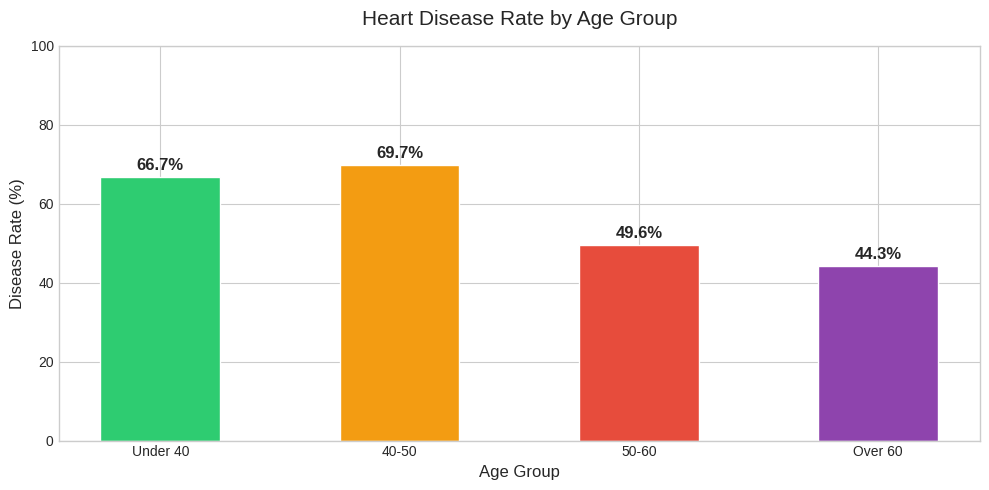

In [ ]:
plt.figure(figsize=(10, 5))

# Calculate disease rate per age group
age_risk = df.groupby('age_group', observed=True)['target'].apply(
    lambda x: (x == 'Disease').sum() / len(x) * 100
).reset_index()
age_risk.columns = ['age_group', 'disease_rate_%']

# Plot
bars = plt.bar(age_risk['age_group'], age_risk['disease_rate_%'],
                color=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'],
                edgecolor='white', width=0.5)

# Add percentage labels on top of each bar
for bar, val in zip(bars, age_risk['disease_rate_%']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Heart Disease Rate by Age Group', fontsize=15, pad=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Disease Rate (%)', fontsize=12)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

### Insight: Age Group Risk Analysis

While the chart shows higher disease rates in younger groups
(Under 40: 66.7%, 40-50: 69.7%), these percentages must be
interpreted carefully alongside sample sizes:

- Under 40 has only **18 patients** — 66.7% represents just 12 people
- 50-60 has **129 patients** — the most reliable group in this dataset
- Percentages from small samples can be misleading without context

This is a key principle in healthcare data analysis — **sample
size directly affects the reliability of any percentage or rate**.
A finding from 18 patients cannot be compared equally to a
finding from 129 patients.

In a real clinical setting, this dataset would require more
younger patient data before drawing conclusions about that age group.

## Conclusion

This EDA uncovered meaningful patterns in clinical heart disease
data - particularly around chest pain type, max heart rate, and
sex-based risk differences. It also highlighted the importance
of interpreting percentages alongside sample sizes, especially
in smaller healthcare datasets.